# Notebook 17 — Network-Augmented Hurdle Model

Extends the baseline hurdle model (nb16) with:
- Per-layer network in-strength and PageRank measures (lagged 1yr)
- Interaction terms: arms x colonial_tie, ODA x colonial_tie, econ x colonial_tie

Both components use clustered standard errors (by recipient_iso3) from the start.
Comparison against nb16 baseline is the primary output.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit, NegativeBinomial
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import pickle
import warnings
warnings.filterwarnings('ignore')

DATA_PATH   = Path('../..') / 'data' / 'merged' / 'panel_final_1992_2024.csv'
MODELS_DIR  = Path('../..') / 'outputs' / 'models'
RESULTS_DIR = Path('../..') / 'outputs' / 'results'
LIMITS_DIR  = Path('../..') / 'outputs' / 'limitations'
METHODS_DIR = Path('../..') / 'outputs' / 'data&methods'

for d in [MODELS_DIR, RESULTS_DIR, LIMITS_DIR, METHODS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RED  = '#BF3A27'   # canonical red — logit / primary / significant
GOLD = '#C7922A'   # canonical gold — negbin / secondary / comparison

print('Paths ready.')

Paths ready.


## Part A — Data Loading and Feature Construction

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')

# Feature lists
baseline_features = [
    'arms_tiv_total_log_lag1',
    'oda_total_log_lag1',
    'econ_neocol_score_total_lag1',
    'colonial_tie_flag',
    'gdp_per_capita_log',
    'population_log',
    'armed_conflict',
    'conflict_intensity'
]

network_only_features = [
    'arms_tiv_in_strength_lag1',
    'bilateral_oda_in_strength_lag1',
    'econ_neocol_score_in_strength_lag1',
    'colonial_tie_in_strength_lag1',
    'arms_tiv_pagerank_lag1',
    'bilateral_oda_pagerank_lag1',
    'econ_neocol_score_pagerank_lag1',
    'colonial_tie_pagerank_lag1'
]

# Interaction terms
df['arms_x_colonial']  = df['arms_tiv_total_log_lag1'] * df['colonial_tie_flag']
df['oda_x_colonial']   = df['oda_total_log_lag1'] * df['colonial_tie_flag']
df['econ_x_colonial']  = df['econ_neocol_score_total_lag1'] * df['colonial_tie_flag']

interaction_features = ['arms_x_colonial', 'oda_x_colonial', 'econ_x_colonial']

network_features = baseline_features + network_only_features
full_features    = network_features + interaction_features

target = 'journalist_killings'
required_cols = full_features + [target, 'recipient_iso3']

# Check all columns exist
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    print(f'MISSING COLUMNS: {missing_cols}')
else:
    print('All required columns present.')

# Drop NaNs
n_before = len(df)
df_model = df.dropna(subset=required_cols).copy()
n_after  = len(df_model)
n_dropped = n_before - n_after

df_positive = df_model[df_model[target] > 0].copy()
df_zero     = df_model[df_model[target] == 0].copy()

print(f'\nSample construction:')
print(f'  Panel rows:              {n_before:,}')
print(f'  After dropna:            {n_after:,}')
print(f'  Dropped:                 {n_dropped:,} ({n_dropped/n_before*100:.1f}%)')
print(f'  Non-zero rows (NegBin):  {len(df_positive):,} ({len(df_positive)/n_after*100:.1f}%)')
print(f'  Zero rows (logit):       {len(df_zero):,} ({len(df_zero)/n_after*100:.1f}%)')

# Save sample construction
sample_tbl = pd.DataFrame([
    {'stage': 'Panel rows',             'n': n_before,          'pct': ''},
    {'stage': 'After dropna',           'n': n_after,           'pct': ''},
    {'stage': 'Dropped',                'n': n_dropped,         'pct': f'{n_dropped/n_before*100:.1f}%'},
    {'stage': 'Non-zero rows (NegBin)', 'n': len(df_positive),  'pct': f'{len(df_positive)/n_after*100:.1f}%'},
    {'stage': 'Zero rows (logit)',      'n': len(df_zero),      'pct': f'{len(df_zero)/n_after*100:.1f}%'},
])
sample_tbl.to_csv(METHODS_DIR / 'nb17_sample_construction.csv', index=False)
print('\nSaved: nb17_sample_construction.csv')

Loaded: 6,358 rows x 38 cols
All required columns present.

Sample construction:
  Panel rows:              6,358
  After dropna:            5,765
  Dropped:                 593 (9.3%)
  Non-zero rows (NegBin):  687 (11.9%)
  Zero rows (logit):       5,078 (88.1%)

Saved: nb17_sample_construction.csv


## Part B — VIF Check

Network measures are derived from the same underlying flows as the predictor variables, so multicollinearity between e.g. arms_tiv_total_log_lag1 and arms_in_strength_lag1 is expected. Flag anything above 10.

In [3]:
X_vif = sm.add_constant(df_model[full_features])
vif_data = pd.DataFrame({
    'feature': full_features,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(full_features))]
}).sort_values('VIF', ascending=False)

vif_data['flag'] = vif_data['VIF'].apply(lambda x: 'HIGH' if x > 10 else '')

print('VIF Table (network-augmented features):')
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\nHIGH VIF (>10): {list(high_vif.feature)}')
    print('These features have severe multicollinearity. Interpret coefficients with caution.')
else:
    print('\nNo VIF > 10. Multicollinearity acceptable.')

vif_data.to_csv(METHODS_DIR / 'vif_nb17_network_features.csv', index=False)
print('Saved: vif_nb17_network_features.csv')

VIF Table (network-augmented features):
                           feature       VIF flag
econ_neocol_score_in_strength_lag1 10.698344 HIGH
    bilateral_oda_in_strength_lag1 10.395600 HIGH
                    oda_x_colonial 10.010455 HIGH
                 colonial_tie_flag  9.742160     
      econ_neocol_score_total_lag1  8.520957     
                    armed_conflict  8.398081     
                conflict_intensity  8.395291     
                oda_total_log_lag1  7.514929     
           arms_tiv_total_log_lag1  6.724743     
                   econ_x_colonial  6.675098     
         arms_tiv_in_strength_lag1  5.398360     
     colonial_tie_in_strength_lag1  4.106653     
       bilateral_oda_pagerank_lag1  3.985302     
                   arms_x_colonial  3.401548     
                    population_log  2.759972     
                gdp_per_capita_log  2.612013     
   econ_neocol_score_pagerank_lag1  2.371705     
            arms_tiv_pagerank_lag1  2.265001     
        co

## Part C — Logistic Regression (Zero Component)

Predicts P(any journalist killing) on full model sample. Clustered SEs by recipient_iso3.

In [4]:
X_logit = sm.add_constant(df_model[full_features])
y_logit = (df_model[target] > 0).astype(int)

logit_model  = Logit(y_logit, X_logit)
logit_result = logit_model.fit(
    cov_type='cluster',
    cov_kwds={'groups': df_model['recipient_iso3']},
    maxiter=200,
    disp=False
)

def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    return ''

logit_table = pd.DataFrame({
    'term':         logit_result.params.index,
    'coef':         logit_result.params.values,
    'std_err':      logit_result.bse.values,
    'z':            logit_result.tvalues.values,
    'p_value':      logit_result.pvalues.values,
    'significance': [sig_stars(p) for p in logit_result.pvalues.values]
})

print('Logistic Regression (Zero Component) — Clustered SEs')
print(f'McFadden pseudo-R2: {logit_result.prsquared:.3f}')
print(f'AIC: {logit_result.aic:.1f}   BIC: {logit_result.bic:.1f}')
print(f'Converged: {logit_result.mle_retvals["converged"]}')
print()
print(logit_table.to_string(index=False))

logit_table.to_csv(METHODS_DIR / 'nb17_logit_coefficients.csv', index=False)
print('\nSaved: nb17_logit_coefficients.csv')

Logistic Regression (Zero Component) — Clustered SEs
McFadden pseudo-R2: 0.284
AIC: 3054.1   BIC: 3187.3
Converged: True

                              term       coef    std_err         z      p_value significance
                             const -14.518866   2.624926 -5.531152 3.181345e-08          ***
           arms_tiv_total_log_lag1  -0.121519   0.088961 -1.365986 1.719432e-01             
                oda_total_log_lag1   0.223921   0.121931  1.836462 6.628930e-02            .
      econ_neocol_score_total_lag1   0.230692   0.091240  2.528412 1.145797e-02            *
                 colonial_tie_flag  -0.082668   0.629556 -0.131312 8.955287e-01             
                gdp_per_capita_log   0.193024   0.088043  2.192384 2.835179e-02            *
                    population_log   0.530284   0.081757  6.486120 8.807524e-11          ***
                    armed_conflict  -0.574524   0.465958 -1.232996 2.175774e-01             
                conflict_intensity   1.61

## Part D — Negative Binomial (Count Component)

Predicts journalist killing count given killing occurred. Non-zero rows only (n = df_positive). Clustered SEs by recipient_iso3.

In [5]:
X_nb = sm.add_constant(df_positive[full_features])
y_nb = df_positive[target]

nb_model  = NegativeBinomial(y_nb, X_nb)
nb_result = nb_model.fit(
    cov_type='cluster',
    cov_kwds={'groups': df_positive['recipient_iso3']},
    maxiter=200,
    disp=False
)

nb_table = pd.DataFrame({
    'term':         nb_result.params.index,
    'coef':         nb_result.params.values,
    'std_err':      nb_result.bse.values,
    'z':            nb_result.tvalues.values,
    'p_value':      nb_result.pvalues.values,
    'significance': [sig_stars(p) for p in nb_result.pvalues.values]
})

alpha_row = nb_table[nb_table['term'] == 'alpha']
alpha_val = alpha_row['coef'].values[0] if len(alpha_row) > 0 else float('nan')

print('Negative Binomial (Count Component) — Clustered SEs')
print(f'Pseudo-R2: {nb_result.prsquared:.3f}')
print(f'AIC: {nb_result.aic:.1f}   BIC: {nb_result.bic:.1f}')
print(f'Alpha (overdispersion): {alpha_val:.3f}')
print(f'Converged: {nb_result.mle_retvals["converged"]}')
print()
print(nb_table.to_string(index=False))

nb_table.to_csv(METHODS_DIR / 'nb17_nb_coefficients.csv', index=False)
print('\nSaved: nb17_nb_coefficients.csv')

Negative Binomial (Count Component) — Clustered SEs
Pseudo-R2: 0.116
AIC: 2863.9   BIC: 2959.1
Alpha (overdispersion): 0.406
Converged: True

                              term        coef    std_err         z      p_value significance
                             const   -1.651787   1.475036 -1.119828 2.627869e-01             
           arms_tiv_total_log_lag1    0.010661   0.046874  0.227447 8.200762e-01             
                oda_total_log_lag1    0.063189   0.074668  0.846275 3.973996e-01             
      econ_neocol_score_total_lag1   -0.004609   0.061487 -0.074954 9.402515e-01             
                 colonial_tie_flag   -0.740250   0.386443 -1.915546 5.542289e-02            .
                gdp_per_capita_log    0.188583   0.062104  3.036589 2.392718e-03           **
                    population_log    0.063723   0.063509  1.003359 3.156879e-01             
                    armed_conflict   -0.985166   0.351088 -2.806038 5.015478e-03           **
            

## Part E — Evaluation Metrics

In [6]:
# Logistic component
logit_probs = logit_result.predict(X_logit)
logit_preds = (logit_probs >= 0.5).astype(int)
logit_auc   = roc_auc_score(y_logit, logit_probs)

print('=== Logistic Component ===')
print(f'ROC-AUC:         {logit_auc:.3f}')
print(f'McFadden R2:     {logit_result.prsquared:.3f}')
print(f'AIC:             {logit_result.aic:.1f}')
print(f'BIC:             {logit_result.bic:.1f}')
print()
print('Classification report (threshold=0.5):')
print(classification_report(y_logit, logit_preds, target_names=['zero', 'killing']))
print('Confusion matrix:')
print(confusion_matrix(y_logit, logit_preds))

# NegBin component
nb_preds = nb_result.predict(X_nb)
nb_mae   = np.mean(np.abs(y_nb - nb_preds))
nb_rmse  = np.sqrt(np.mean((y_nb - nb_preds)**2))

print()
print('=== NegBin Component ===')
print(f'MAE:    {nb_mae:.3f}')
print(f'RMSE:   {nb_rmse:.3f}')
print(f'AIC:    {nb_result.aic:.1f}')
print(f'BIC:    {nb_result.bic:.1f}')

# Save metrics
logit_metrics = pd.DataFrame([{
    'auc': logit_auc,
    'mcfadden_r2': logit_result.prsquared,
    'aic': logit_result.aic,
    'bic': logit_result.bic
}])
logit_metrics.to_csv(METHODS_DIR / 'nb17_logit_metrics.csv', index=False)

nb_metrics = pd.DataFrame([{
    'mae': nb_mae,
    'rmse': nb_rmse,
    'aic': nb_result.aic,
    'bic': nb_result.bic,
    'alpha': alpha_val
}])
nb_metrics.to_csv(METHODS_DIR / 'nb17_nb_metrics.csv', index=False)
print('\nSaved: nb17_logit_metrics.csv, nb17_nb_metrics.csv')

=== Logistic Component ===
ROC-AUC:         0.857
McFadden R2:     0.284
AIC:             3054.1
BIC:             3187.3

Classification report (threshold=0.5):
              precision    recall  f1-score   support

        zero       0.91      0.98      0.94      5078
     killing       0.66      0.32      0.43       687

    accuracy                           0.90      5765
   macro avg       0.79      0.65      0.69      5765
weighted avg       0.88      0.90      0.88      5765

Confusion matrix:
[[4966  112]
 [ 467  220]]

=== NegBin Component ===
MAE:    2.304
RMSE:   5.565
AIC:    2863.9
BIC:    2959.1

Saved: nb17_logit_metrics.csv, nb17_nb_metrics.csv


## Part F — Comparison vs Baseline (nb16)

Loads nb16 coefficient tables and compares shared baseline features. Flags sign flips and significance changes.

Note: nb16 coefficients were estimated with nonrobust standard errors; nb17 uses clustered standard errors throughout. Significance changes in the comparison table partly reflect this SE methodology difference, not solely the addition of network features.

In [7]:
# Load nb16 coefficient tables
nb16_logit = pd.read_csv(RESULTS_DIR / 'nb16_logit_any_killing_coefficients.csv')
nb16_nb    = pd.read_csv(RESULTS_DIR / 'nb16_negative_binomial_positive_counts_coefficients.csv')

def sig_bracket(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    return 'ns'

rows = []
for feat in baseline_features:
    l16 = nb16_logit[nb16_logit['term'] == feat]
    l17 = logit_table[logit_table['term'] == feat]
    n16 = nb16_nb[nb16_nb['term'] == feat]
    n17 = nb_table[nb_table['term'] == feat]

    l16_coef = l16['coef'].values[0] if len(l16) > 0 else np.nan
    l17_coef = l17['coef'].values[0] if len(l17) > 0 else np.nan
    l16_p    = l16['p_value'].values[0] if len(l16) > 0 else np.nan
    l17_p    = l17['p_value'].values[0] if len(l17) > 0 else np.nan
    n16_coef = n16['coef'].values[0] if len(n16) > 0 else np.nan
    n17_coef = n17['coef'].values[0] if len(n17) > 0 else np.nan
    n16_p    = n16['p_value'].values[0] if len(n16) > 0 else np.nan
    n17_p    = n17['p_value'].values[0] if len(n17) > 0 else np.nan

    logit_sign_flip = np.sign(l16_coef) != np.sign(l17_coef) if not (np.isnan(l16_coef) or np.isnan(l17_coef)) else False
    nb_sign_flip    = np.sign(n16_coef) != np.sign(n17_coef) if not (np.isnan(n16_coef) or np.isnan(n17_coef)) else False
    logit_sig_chg   = sig_bracket(l16_p) != sig_bracket(l17_p) if not (np.isnan(l16_p) or np.isnan(l17_p)) else False
    nb_sig_chg      = sig_bracket(n16_p) != sig_bracket(n17_p) if not (np.isnan(n16_p) or np.isnan(n17_p)) else False

    rows.append({
        'predictor':      feat,
        'logit_coef_nb16': round(l16_coef, 3), 'logit_coef_nb17': round(l17_coef, 3),
        'logit_p_nb16':    round(l16_p, 3),    'logit_p_nb17':    round(l17_p, 3),
        'logit_sig_nb16':  sig_bracket(l16_p), 'logit_sig_nb17':  sig_bracket(l17_p),
        'logit_sign_flip': logit_sign_flip,    'logit_sig_chg':   logit_sig_chg,
        'nb_coef_nb16':    round(n16_coef, 3), 'nb_coef_nb17':    round(n17_coef, 3),
        'nb_p_nb16':       round(n16_p, 3),    'nb_p_nb17':       round(n17_p, 3),
        'nb_sig_nb16':     sig_bracket(n16_p), 'nb_sig_nb17':     sig_bracket(n17_p),
        'nb_sign_flip':    nb_sign_flip,       'nb_sig_chg':      nb_sig_chg
    })

cmp_table = pd.DataFrame(rows)
print('Baseline feature comparison: nb16 vs nb17')
print(cmp_table[['predictor','logit_coef_nb16','logit_coef_nb17','logit_sig_nb16','logit_sig_nb17',
                  'nb_coef_nb16','nb_coef_nb17','nb_sig_nb16','nb_sig_nb17']].to_string(index=False))

print('\nSign flips (logit):', list(cmp_table[cmp_table['logit_sign_flip']]['predictor']))
print('Sign flips (NegBin):', list(cmp_table[cmp_table['nb_sign_flip']]['predictor']))
print('Sig changes (logit):', list(cmp_table[cmp_table['logit_sig_chg']]['predictor']))
print('Sig changes (NegBin):', list(cmp_table[cmp_table['nb_sig_chg']]['predictor']))

print('\nNetwork-only features:')
net_coefs = logit_table[logit_table['term'].isin(network_only_features)][['term','coef','p_value','significance']].copy()
net_coefs.columns = ['term','logit_coef','logit_p','logit_sig']
nb_net = nb_table[nb_table['term'].isin(network_only_features)][['term','coef','p_value','significance']].copy()
nb_net.columns = ['term','nb_coef','nb_p','nb_sig']
net_summary = net_coefs.merge(nb_net, on='term', how='outer')
print(net_summary.to_string(index=False))

print('\nInteraction terms:')
int_coefs = logit_table[logit_table['term'].isin(interaction_features)][['term','coef','p_value','significance']].copy()
int_coefs.columns = ['term','logit_coef','logit_p','logit_sig']
nb_int = nb_table[nb_table['term'].isin(interaction_features)][['term','coef','p_value','significance']].copy()
nb_int.columns = ['term','nb_coef','nb_p','nb_sig']
int_summary = int_coefs.merge(nb_int, on='term', how='outer')
print(int_summary.to_string(index=False))

cmp_table.to_csv(RESULTS_DIR / 'nb17_vs_nb16_comparison.csv', index=False)
net_summary.to_csv(RESULTS_DIR / 'nb17_network_features_summary.csv', index=False)
int_summary.to_csv(RESULTS_DIR / 'nb17_interaction_terms_summary.csv', index=False)
print('\nSaved comparison CSVs.')

Baseline feature comparison: nb16 vs nb17
                   predictor  logit_coef_nb16  logit_coef_nb17 logit_sig_nb16 logit_sig_nb17  nb_coef_nb16  nb_coef_nb17 nb_sig_nb16 nb_sig_nb17
     arms_tiv_total_log_lag1           -0.079           -0.122             **             ns        -0.033         0.011          ns          ns
          oda_total_log_lag1            0.182            0.224            ***              .         0.058         0.063           *          ns
econ_neocol_score_total_lag1           -0.028            0.231             ns              *        -0.032        -0.005           .          ns
           colonial_tie_flag            0.488           -0.083            ***             ns         0.308        -0.740          **           .
          gdp_per_capita_log            0.215            0.193            ***              *         0.246         0.189         ***          **
              population_log            0.552            0.530            ***           

## Part G — IRQ/SYR Sensitivity (ODA Robustness)

In [8]:
df_no_crisis   = df_model[~df_model['recipient_iso3'].isin(['IRQ', 'SYR'])].copy()
df_pos_nocrisis = df_no_crisis[df_no_crisis[target] > 0].copy()

print(f'Rows excl. IRQ/SYR: {len(df_no_crisis):,} (dropped {len(df_model)-len(df_no_crisis)} rows)')

X_logit_nc = sm.add_constant(df_no_crisis[full_features])
y_logit_nc = (df_no_crisis[target] > 0).astype(int)
logit_nc = Logit(y_logit_nc, X_logit_nc).fit(
    cov_type='cluster', cov_kwds={'groups': df_no_crisis['recipient_iso3']},
    maxiter=200, disp=False
)

X_nb_nc = sm.add_constant(df_pos_nocrisis[full_features])
y_nb_nc = df_pos_nocrisis[target]
nb_nc = NegativeBinomial(y_nb_nc, X_nb_nc).fit(
    cov_type='cluster', cov_kwds={'groups': df_pos_nocrisis['recipient_iso3']},
    maxiter=200, disp=False
)

oda_sensitivity = pd.DataFrame([
    {'model': 'Logit',  'sample': 'Full',          'oda_coef': round(logit_result.params.get('oda_total_log_lag1', np.nan), 3), 'oda_p': round(logit_result.pvalues.get('oda_total_log_lag1', np.nan), 3)},
    {'model': 'Logit',  'sample': 'Excl. IRQ/SYR', 'oda_coef': round(logit_nc.params.get('oda_total_log_lag1', np.nan), 3),    'oda_p': round(logit_nc.pvalues.get('oda_total_log_lag1', np.nan), 3)},
    {'model': 'NegBin', 'sample': 'Full',          'oda_coef': round(nb_result.params.get('oda_total_log_lag1', np.nan), 3),   'oda_p': round(nb_result.pvalues.get('oda_total_log_lag1', np.nan), 3)},
    {'model': 'NegBin', 'sample': 'Excl. IRQ/SYR', 'oda_coef': round(nb_nc.params.get('oda_total_log_lag1', np.nan), 3),      'oda_p': round(nb_nc.pvalues.get('oda_total_log_lag1', np.nan), 3)},
])

print('ODA coefficient sensitivity (IRQ/SYR exclusion):')
print(oda_sensitivity.to_string(index=False))

oda_sensitivity.to_csv(LIMITS_DIR / 'nb17_oda_irq_syr_sensitivity.csv', index=False)
print('Saved: nb17_oda_irq_syr_sensitivity.csv')

Rows excl. IRQ/SYR: 5,703 (dropped 62 rows)
ODA coefficient sensitivity (IRQ/SYR exclusion):
 model        sample  oda_coef  oda_p
 Logit          Full     0.224  0.066
 Logit Excl. IRQ/SYR     0.231  0.066
NegBin          Full     0.063  0.397
NegBin Excl. IRQ/SYR     0.080  0.344
Saved: nb17_oda_irq_syr_sensitivity.csv


## Part H — Conflict Collinearity Robustness Check

Drops armed_conflict (binary), keeps conflict_intensity (graded). VIF ~8 between them in nb16. Check coefficient stability.

In [9]:
full_features_nc = [f for f in full_features if f != 'armed_conflict']

X_logit_r = sm.add_constant(df_model[full_features_nc])
logit_r = Logit(y_logit, X_logit_r).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['recipient_iso3']},
    maxiter=200, disp=False
)

X_nb_r = sm.add_constant(df_positive[full_features_nc])
nb_r = NegativeBinomial(y_nb, X_nb_r).fit(
    cov_type='cluster', cov_kwds={'groups': df_positive['recipient_iso3']},
    maxiter=200, disp=False
)

conflict_rows = []
for feat in baseline_features:
    full_lc = logit_result.params.get(feat, np.nan)
    red_lc  = logit_r.params.get(feat, np.nan)
    full_lp = logit_result.pvalues.get(feat, np.nan)
    red_lp  = logit_r.pvalues.get(feat, np.nan)
    full_nc = nb_result.params.get(feat, np.nan)
    red_nc  = nb_r.params.get(feat, np.nan)
    full_np = nb_result.pvalues.get(feat, np.nan)
    red_np  = nb_r.pvalues.get(feat, np.nan)
    conflict_rows.append({
        'predictor':         feat,
        'logit_coef_full':   round(full_lc, 3), 'logit_coef_reduced': round(red_lc, 3) if not np.isnan(red_lc) else 'dropped',
        'logit_p_full':      round(full_lp, 3), 'logit_p_reduced':    round(red_lp, 3) if not np.isnan(red_lp) else 'dropped',
        'nb_coef_full':      round(full_nc, 3), 'nb_coef_reduced':    round(red_nc, 3) if not np.isnan(red_nc) else 'dropped',
        'nb_p_full':         round(full_np, 3), 'nb_p_reduced':       round(red_np, 3) if not np.isnan(red_np) else 'dropped',
    })

conflict_tbl = pd.DataFrame(conflict_rows)
print('Conflict robustness: full model vs armed_conflict dropped')
print(conflict_tbl[['predictor','logit_coef_full','logit_coef_reduced','nb_coef_full','nb_coef_reduced']].to_string(index=False))

conflict_tbl.to_csv(LIMITS_DIR / 'nb17_conflict_robustness.csv', index=False)
print('Saved: nb17_conflict_robustness.csv')

Conflict robustness: full model vs armed_conflict dropped
                   predictor  logit_coef_full logit_coef_reduced  nb_coef_full nb_coef_reduced
     arms_tiv_total_log_lag1           -0.122             -0.116         0.011          -0.009
          oda_total_log_lag1            0.224              0.221         0.063           0.059
econ_neocol_score_total_lag1            0.231              0.225        -0.005           0.001
           colonial_tie_flag           -0.083             -0.103        -0.740          -0.761
          gdp_per_capita_log            0.193              0.193         0.189           0.217
              population_log            0.530              0.516         0.064           0.021
              armed_conflict           -0.575            dropped        -0.985         dropped
          conflict_intensity            1.610              1.239         1.231           0.717
Saved: nb17_conflict_robustness.csv


## Part I — Figures

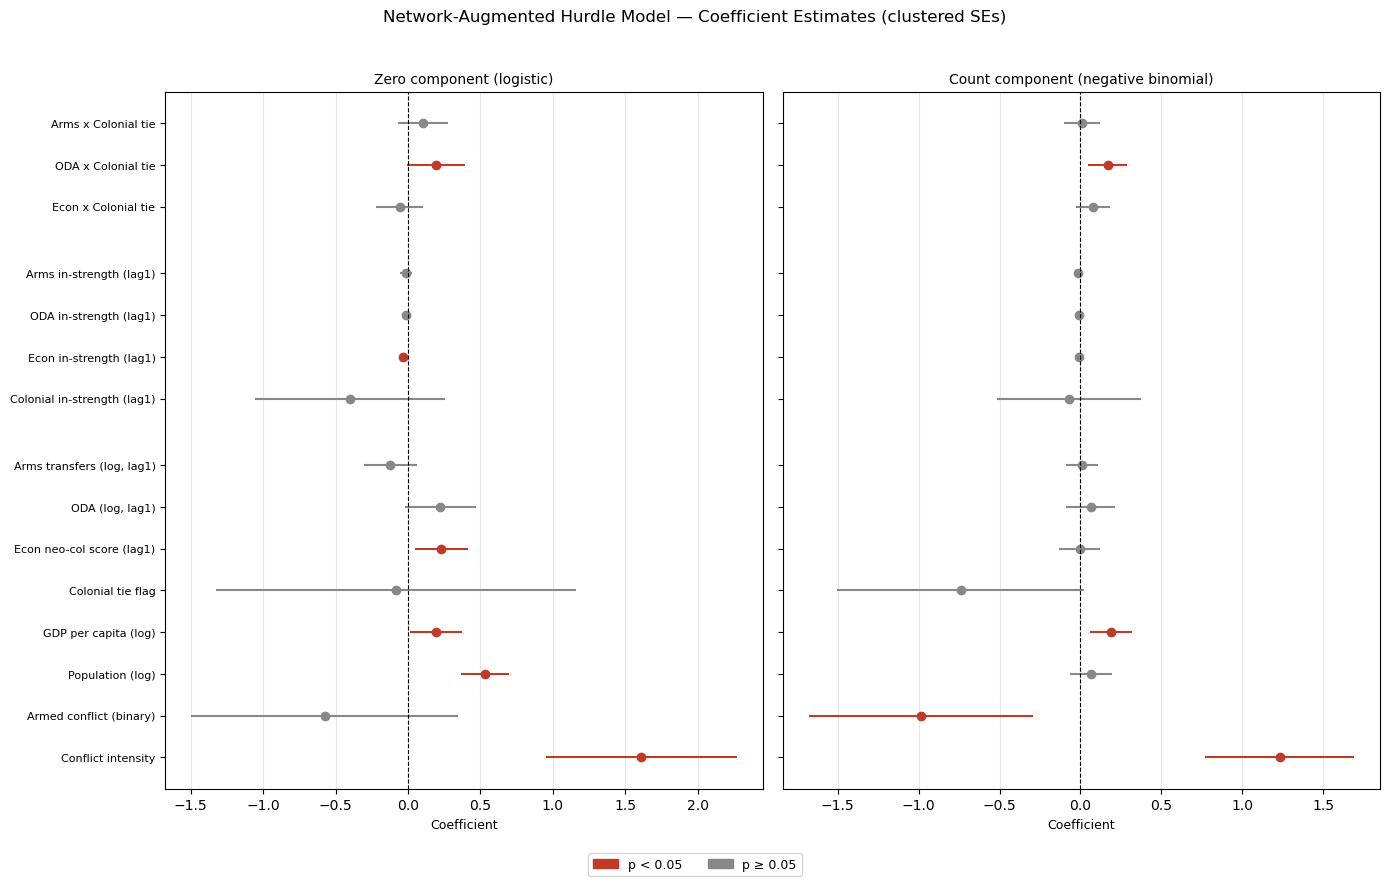

Saved: nb17_coefficient_forest.png


In [10]:
# Figure 1 — Forest plot (network-augmented, grouped)
# PageRank features remain in the model and coefficient CSVs but are excluded from the visual
# (their extreme scale / near-uniform distributions distort the axis)
LABEL_MAP = {
    'arms_tiv_total_log_lag1':                'Arms transfers (log, lag1)',
    'oda_total_log_lag1':                     'ODA (log, lag1)',
    'econ_neocol_score_total_lag1':           'Econ neo-col score (lag1)',
    'colonial_tie_flag':                      'Colonial tie flag',
    'gdp_per_capita_log':                     'GDP per capita (log)',
    'population_log':                         'Population (log)',
    'armed_conflict':                         'Armed conflict (binary)',
    'conflict_intensity':                     'Conflict intensity',
    'arms_tiv_in_strength_lag1':              'Arms in-strength (lag1)',
    'bilateral_oda_in_strength_lag1':         'ODA in-strength (lag1)',
    'econ_neocol_score_in_strength_lag1':     'Econ in-strength (lag1)',
    'colonial_tie_in_strength_lag1':          'Colonial in-strength (lag1)',
    'arms_x_colonial':                        'Arms x Colonial tie',
    'oda_x_colonial':                         'ODA x Colonial tie',
    'econ_x_colonial':                        'Econ x Colonial tie',
}

PAGERANK_FEATURES = [
    'arms_tiv_pagerank_lag1',
    'bilateral_oda_pagerank_lag1',
    'econ_neocol_score_pagerank_lag1',
    'colonial_tie_pagerank_lag1',
]

plot_network_features = [f for f in network_only_features if f not in PAGERANK_FEATURES]

group_labels = {
    'Baseline predictors':  baseline_features,
    'Network in-strength':  plot_network_features,
    'Interaction terms':    interaction_features,
}

def color_by_p(p):
    return RED if p < 0.05 else '#888888'

fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=True)
fig.suptitle('Network-Augmented Hurdle Model — Coefficient Estimates (clustered SEs)', fontsize=12, y=0.98)

for ax, (res, tbl, title) in zip(axes, [
    (logit_result, logit_table, 'Zero component (logistic)'),
    (nb_result,    nb_table,    'Count component (negative binomial)')
]):
    y_pos = 0
    yticks, ylabels = [], []

    for grp_name, feats in group_labels.items():
        for feat in reversed(feats):
            row = tbl[tbl['term'] == feat]
            if len(row) == 0:
                y_pos += 1
                continue
            coef = row['coef'].values[0]
            se   = row['std_err'].values[0]
            p    = row['p_value'].values[0]
            ci_lo, ci_hi = coef - 1.96*se, coef + 1.96*se
            c = color_by_p(p)
            ax.plot([ci_lo, ci_hi], [y_pos, y_pos], color=c, linewidth=1.5)
            ax.plot(coef, y_pos, 'o', color=c, markersize=6)
            yticks.append(y_pos)
            ylabels.append(LABEL_MAP.get(feat, feat))
            y_pos += 1
        y_pos += 0.6  # gap between groups

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Coefficient', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

patches = [
    mpatches.Patch(color=RED,       label='p < 0.05'),
    mpatches.Patch(color='#888888', label='p ≥ 0.05'),
]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig(RESULTS_DIR / 'nb17_coefficient_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb17_coefficient_forest.png')

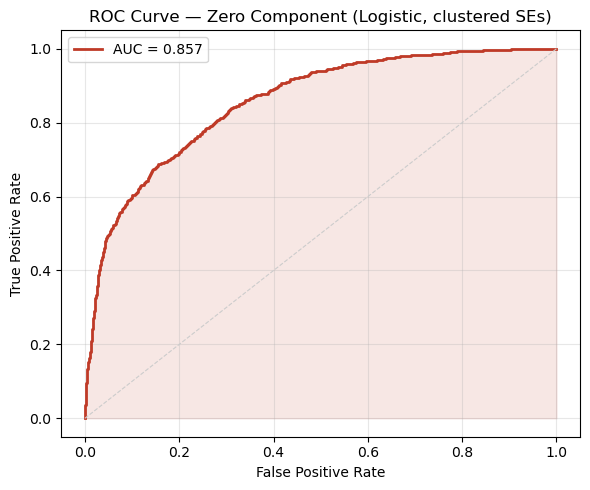

Saved: nb17_roc_curve.png


In [11]:
# Figure 2 — ROC curve
fpr, tpr, _ = roc_curve(y_logit, logit_probs)
auc_val = roc_auc_score(y_logit, logit_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=RED, linewidth=2, label=f'AUC = {auc_val:.3f}')
ax.fill_between(fpr, tpr, alpha=0.12, color=RED)
ax.plot([0, 1], [0, 1], color='#cccccc', linewidth=0.8, linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Zero Component (Logistic, clustered SEs)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'nb17_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb17_roc_curve.png')

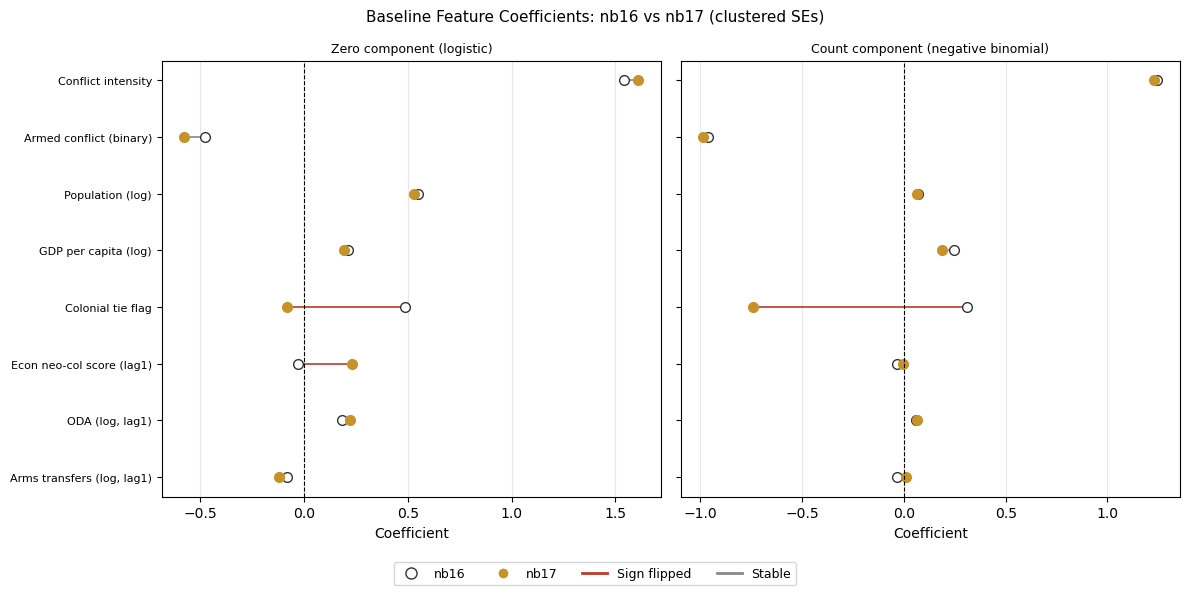

Saved: nb17_vs_nb16_forest.png


In [12]:
# Figure 3 — nb16 vs nb17 baseline feature comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig.suptitle('Baseline Feature Coefficients: nb16 vs nb17 (clustered SEs)', fontsize=11)

for ax, coef_col16, coef_col17, p_col17, title in zip(
    axes,
    ['logit_coef_nb16', 'nb_coef_nb16'],
    ['logit_coef_nb17', 'nb_coef_nb17'],
    ['logit_sig_nb17',  'nb_sig_nb17'],
    ['Zero component (logistic)', 'Count component (negative binomial)']
):
    for i, row in cmp_table.iterrows():
        y = i
        c16 = row[coef_col16]
        c17 = row[coef_col17]
        sign_flip = row['logit_sign_flip'] if 'logit' in coef_col16 else row['nb_sign_flip']
        line_color = RED if sign_flip else '#888888'
        ax.plot([c16, c17], [y, y], color=line_color, linewidth=1.2)
        ax.plot(c16, y, 'o', color='white', markeredgecolor='#333', markersize=7, linewidth=1.5)
        ax.plot(c17, y, 'o', color=GOLD, markersize=7)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(cmp_table)))
    ax.set_yticklabels([LABEL_MAP.get(f, f) for f in cmp_table['predictor']], fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Coefficient')
    ax.grid(axis='x', alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='white', markeredgecolor='#333', markersize=8, label='nb16'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=GOLD, markersize=8, label='nb17'),
    Line2D([0],[0], color=RED, linewidth=2, label='Sign flipped'),
    Line2D([0],[0], color='#888888', linewidth=2, label='Stable')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig(RESULTS_DIR / 'nb17_vs_nb16_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb17_vs_nb16_forest.png')

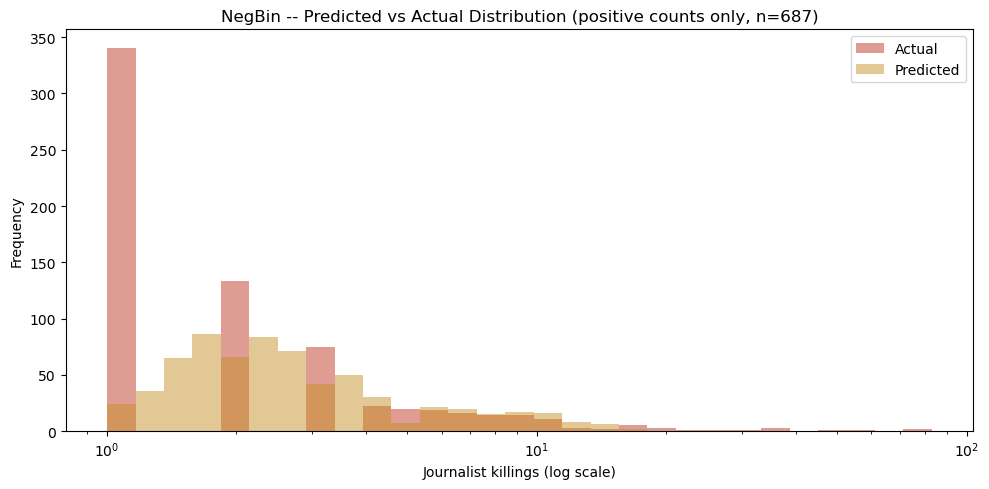

Saved: nb17_predicted_vs_actual.png


In [13]:
# Figure 4 — Predicted vs actual NegBin
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.logspace(0, np.log10(max(y_nb.max(), nb_preds.max()) + 1), 30)
ax.hist(y_nb,     bins=bins, alpha=0.5, label='Actual',    color=RED)
ax.hist(nb_preds, bins=bins, alpha=0.5, label='Predicted', color=GOLD)
ax.set_xscale('log')
ax.set_xlabel('Journalist killings (log scale)')
ax.set_ylabel('Frequency')
ax.set_title(f'NegBin -- Predicted vs Actual Distribution (positive counts only, n={len(y_nb)})')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'nb17_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb17_predicted_vs_actual.png')

## Part J — Save Models and Key Findings Summary

In [14]:
# Save pickles
with open(MODELS_DIR / 'nb17_logit_result.pkl', 'wb') as f:
    pickle.dump(logit_result, f)
with open(MODELS_DIR / 'nb17_nb_result.pkl', 'wb') as f:
    pickle.dump(nb_result, f)
print('Models saved to outputs/models/')

# AIC/BIC comparison
nb16_logit_metrics = pd.read_csv(RESULTS_DIR / 'nb16_logit_any_killing_metrics.csv')
nb16_nb_metrics    = pd.read_csv(RESULTS_DIR / 'nb16_negative_binomial_positive_counts_metrics.csv')

print('\n=== AIC/LLF Comparison: nb16 vs nb17 ===')
print(f'Logit  AIC: nb16={nb16_logit_metrics["aic"].values[0]:.1f}  nb17={logit_result.aic:.1f}  (lower=better)')
print(f'Logit  LLF: nb16={nb16_logit_metrics["log_likelihood"].values[0]:.1f}  nb17={logit_result.llf:.1f}')
print(f'NegBin AIC: nb16={nb16_nb_metrics["aic"].values[0]:.1f}  nb17={nb_result.aic:.1f}  (lower=better)')
print(f'NegBin LLF: nb16={nb16_nb_metrics["log_likelihood"].values[0]:.1f}  nb17={nb_result.llf:.1f}')

# Interaction term significance summary
print('\n=== Interaction Terms (core theoretical test) ===')
for feat in interaction_features:
    l_row = logit_table[logit_table['term'] == feat]
    n_row = nb_table[nb_table['term'] == feat]
    l_str = f"logit: {l_row['coef'].values[0]:.3f} ({l_row['significance'].values[0]})" if len(l_row) > 0 else 'logit: N/A'
    n_str = f"NegBin: {n_row['coef'].values[0]:.3f} ({n_row['significance'].values[0]})" if len(n_row) > 0 else 'NegBin: N/A'
    print(f'  {feat}: {l_str} | {n_str}')

# Network features significance summary
print('\n=== Network Features ===')
for feat in network_only_features:
    l_row = logit_table[logit_table['term'] == feat]
    n_row = nb_table[nb_table['term'] == feat]
    l_str = f"logit: {l_row['coef'].values[0]:.3f} ({l_row['significance'].values[0]})" if len(l_row) > 0 else 'logit: N/A'
    n_str = f"NegBin: {n_row['coef'].values[0]:.3f} ({n_row['significance'].values[0]})" if len(n_row) > 0 else 'NegBin: N/A'
    print(f'  {feat}: {l_str} | {n_str}')

print('\n=== Summary ===')
print(f'Sample: {n_after:,} rows ({n_dropped} dropped, {n_dropped/n_before*100:.1f}%)')
print(f'Logit AUC: {logit_auc:.3f} | McFadden R2: {logit_result.prsquared:.3f}')
print(f'NegBin alpha: {alpha_val:.3f} (overdispersion confirmed)')
print('Key flags:')
print('  - Interaction terms: check output above for neo-colonial hypothesis test')
print('  - econ_neocol_score: null at baseline -- does econ_x_colonial recover signal?')
print('  - ODA: IRQ/SYR sensitivity result in outputs/limitations/')
print('  - Network in-strength vs PageRank: arms/colonial use in-strength (PageRank near-uniform)')

Models saved to outputs/models/

=== AIC/LLF Comparison: nb16 vs nb17 ===
Logit  AIC: nb16=3097.2  nb17=3054.1  (lower=better)
Logit  LLF: nb16=-1539.6  nb17=-1507.1
NegBin AIC: nb16=2899.3  nb17=2863.9  (lower=better)
NegBin LLF: nb16=-1439.7  nb17=-1410.9

=== Interaction Terms (core theoretical test) ===
  arms_x_colonial: logit: 0.102 () | NegBin: 0.010 ()
  oda_x_colonial: logit: 0.196 (*) | NegBin: 0.167 (**)
  econ_x_colonial: logit: -0.058 () | NegBin: 0.078 ()

=== Network Features ===
  arms_tiv_in_strength_lag1: logit: -0.014 () | NegBin: -0.015 ()
  bilateral_oda_in_strength_lag1: logit: -0.010 () | NegBin: -0.009 ()
  econ_neocol_score_in_strength_lag1: logit: -0.031 (**) | NegBin: -0.012 (.)
  colonial_tie_in_strength_lag1: logit: -0.402 () | NegBin: -0.073 ()
  arms_tiv_pagerank_lag1: logit: 33.635 () | NegBin: 5.328 ()
  bilateral_oda_pagerank_lag1: logit: 41.501 () | NegBin: 101.000 (*)
  econ_neocol_score_pagerank_lag1: logit: 57.369 () | NegBin: 0.149 ()
  colonial_t